In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [2]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import numpy as np

In [4]:
df = pd.read_csv("data/merged_data.csv")

In [5]:
df.head()

,year,value,country_name,indicator_id,indicator_name,unit_type
0,2024,NaN,United Arab Emirates,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
1,2023,1.0,United Arab Emirates,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
2,2022,1.0,United Arab Emirates,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
3,2021,1.0,United Arab Emirates,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)
4,2020,1.0,United Arab Emirates,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0)


In [6]:
df.info

<bound method DataFrame.info of        year        value          country_name    indicator_id  \
0      2024          NaN  United Arab Emirates  SG.APL.PSPT.EQ   
1      2023          1.0  United Arab Emirates  SG.APL.PSPT.EQ   
2      2022          1.0  United Arab Emirates  SG.APL.PSPT.EQ   
3      2021          1.0  United Arab Emirates  SG.APL.PSPT.EQ   
4      2020          1.0  United Arab Emirates  SG.APL.PSPT.EQ   
...     ...          ...                   ...             ...   
25686  2018  90,34999847               Tunisia    LR.AG25T64.M   
25687  2019  90,76999664               Tunisia    LR.AG25T64.M   
25688  2021  93,79000092               Tunisia    LR.AG25T64.M   
25689  2022   94,8624098               Tunisia    LR.AG25T64.M   
25690  2023  95,12999725               Tunisia    LR.AG25T64.M   

                                          indicator_name     unit_type  
0      A woman can apply for a passport in the same w...  Binary (1/0)  
1      A woman can apply for 

In [7]:
columns_order = ['country_name','year','indicator_id','indicator_name','value','unit_type']
df = df[columns_order]

In [8]:
df.head()

,country_name,year,indicator_id,indicator_name,value,unit_type
0,United Arab Emirates,2024,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,NaN,Binary (1/0)
1,United Arab Emirates,2023,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,1.0,Binary (1/0)
2,United Arab Emirates,2022,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,1.0,Binary (1/0)
3,United Arab Emirates,2021,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,1.0,Binary (1/0)
4,United Arab Emirates,2020,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,1.0,Binary (1/0)


In [9]:
df.duplicated().sum()

0

# Dealing with Nulls

In [10]:
df.isna().sum()

country_name         0
year                 0
indicator_id         0
indicator_name       0
value             5911
unit_type            0
dtype: int64

## Filtering out fully empty indicators

In [11]:
empty_indicators = (
    df.groupby("indicator_id")['value']
    .apply(lambda x: x.isna().all())
    )

empty_indicators = empty_indicators[empty_indicators].index.tolist()

print(f"Indicators with no data: {len(empty_indicators)}")
print(empty_indicators[:10])

Indicators with no data: 0
[]


In [12]:
df.groupby('indicator_id')['value'].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(20)

indicator_id
SP.M18.2024.FE.ZS       426
SP.M15.2024.FE.ZS       426
SP.DYN.CONM.ZS          394
SP.DYN.CONU.ZS          391
SI.POV.GINI             390
SE.ADT.LITR.ZS          319
SE.ADT.LITR.MA.ZS       319
SE.ADT.1524.LT.MA.ZS    319
SE.ADT.LITR.FE.ZS       316
SE.ADT.1524.LT.FE.ZS    310
SE.SEC.CUAT.UP.MA.ZS    302
SE.SEC.CUAT.UP.FE.ZS    301
SG.GEN.MNST.ZS          236
SE.ENR.SECO.FM.ZS       229
FP.CPI.TOTL.ZG          161
HD.HCI.OVRL.MA          141
HD.HCI.OVRL.FE          141
HD.HCI.OVRL             138
SG.GEN.PARL.ZS           54
SL.EMP.VULN.MA.ZS        19
Name: value, dtype: int64

## Cleaning out the Education Indicators 

In [13]:
unesco_inds = ['Literacy rate, population 25-64 years, male (%)','Literacy rate, population 25-64 years, female (%)',
          'Youth literacy rate, population 15-24 years, male (%)','Youth literacy rate, population 15-24 years, female (%)',
          'Educational attainment rate, completed upper secondary education or higher, population 25+ years, male (%)',
          'Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)'
          ]

In [14]:
df.columns

Index(['country_name', 'year', 'indicator_id', 'indicator_name', 'value',
       'unit_type'],
      dtype='object')

In [15]:
df['source'] = df['indicator_name'].apply(lambda x: 'UNESCO' if x in unesco_inds else 'WHO')

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_3874/3233479249.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['source'] = df['indicator_name'].apply(lambda x: 'UNESCO' if x in unesco_inds else 'WHO')


In [16]:
df['source'].value_counts()

source
WHO       24894
UNESCO      797
Name: count, dtype: int64

In [17]:
unesco_edu_indicators = (
    df[df["source"]=="UNESCO"]["indicator_name"]
    .unique()
    .tolist()
)

who_edu_indicators = ['Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)',
        "Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)",
        "Literacy rate, adult female (% of females ages 15 and above)",
        "Literacy rate, adult male (% of males ages 15 and above)",
        "Literacy rate, adult total (% of people ages 15 and above)",
        "Literacy rate, youth female (% of females ages 15-24)",
        "Literacy rate, youth male (% of males ages 15-24)"
        ]


In [18]:
unesco_edu_df = df[df["indicator_name"].isin(unesco_edu_indicators)]
who_edu_df = df[df["indicator_name"].isin(who_edu_indicators)]



In [19]:
unesco_nulls = (
    df[df["indicator_name"].isin(unesco_edu_indicators)]
    .isna()
    .sum()
)


In [20]:
unesco_nulls

country_name      0
year              0
indicator_id      0
indicator_name    0
value             0
unit_type         0
source            0
dtype: int64

In [21]:
who_nulls = (
    df[df["indicator_name"].isin(who_edu_indicators)]
    .isna()
    .sum()
)

who_nulls


country_name         0
year                 0
indicator_id         0
indicator_name       0
value             2186
unit_type            0
source               0
dtype: int64

In [22]:
who_nulls_detail = (
    df[df["indicator_name"].isin(who_edu_indicators)]
    .groupby("indicator_name")["value"]
    .apply(lambda x: x.isna().sum())
)

who_nulls_detail

indicator_name
Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)    301
Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)      302
Literacy rate, adult female (% of females ages 15 and above)                                           316
Literacy rate, adult male (% of males ages 15 and above)                                               319
Literacy rate, adult total (% of people ages 15 and above)                                             319
Literacy rate, youth female (% of females ages 15-24)                                                  310
Literacy rate, youth male (% of males ages 15-24)                                                      319
Name: value, dtype: int64

In [23]:
unesco_nulls_detail = (
    df[df["indicator_name"].isin(unesco_edu_indicators)]
    .groupby("indicator_name")["value"]
    .apply(lambda x: x.isna().sum())
)

unesco_nulls_detail


indicator_name
Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)    0
Educational attainment rate, completed upper secondary education or higher, population 25+ years, male (%)      0
Literacy rate, population 25-64 years, female (%)                                                               0
Literacy rate, population 25-64 years, male (%)                                                                 0
Youth literacy rate, population 15-24 years, female (%)                                                         0
Youth literacy rate, population 15-24 years, male (%)                                                           0
Name: value, dtype: int64

In [24]:
unesco_years = (
    unesco_edu_df.groupby(["indicator_name", "country_name"])["year"]
    .apply(set)
    .to_dict()
)

print(unesco_years)

{('Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)', 'Algeria'): {2008, 2011, 2006, 2019}, ('Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)', 'Bahrain'): {2016, 2017, 2018, 2020, 2022, 2023, 2001, 2010}, ('Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)', 'Egypt, Arab Rep.'): {2016, 2017, 2018, 2021, 2022, 2023, 2006, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015}, ('Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)', 'Iran, Islamic Rep.'): {2016, 2019, 2020, 2021, 2022, 2023, 2006, 2008, 2010, 2012, 2013, 2014}, ('Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)', 'Iraq'): {2021, 2018, 2013, 2007}, ('Educational attainment rate, completed upper secondary education or higher, population 

In [25]:
full_years = set(range(2000,2024))

In [26]:
expanded_years = {}

for key, years_present in unesco_years.items():
    expanded_years[key] = {
        yr: ("EXISTS" if yr in years_present else None)
        for yr in sorted(full_years)
    }

In [27]:
print(expanded_years)

{('Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)', 'Algeria'): {2000: None, 2001: None, 2002: None, 2003: None, 2004: None, 2005: None, 2006: 'EXISTS', 2007: None, 2008: 'EXISTS', 2009: None, 2010: None, 2011: 'EXISTS', 2012: None, 2013: None, 2014: None, 2015: None, 2016: None, 2017: None, 2018: None, 2019: 'EXISTS', 2020: None, 2021: None, 2022: None, 2023: None}, ('Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)', 'Bahrain'): {2000: None, 2001: 'EXISTS', 2002: None, 2003: None, 2004: None, 2005: None, 2006: None, 2007: None, 2008: None, 2009: None, 2010: 'EXISTS', 2011: None, 2012: None, 2013: None, 2014: None, 2015: None, 2016: 'EXISTS', 2017: 'EXISTS', 2018: 'EXISTS', 2019: None, 2020: 'EXISTS', 2021: None, 2022: 'EXISTS', 2023: 'EXISTS'}, ('Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)', 'Egypt, 

In [28]:
# Turn it into a dataframe

rows= []
for (indicator, country), years_dict in expanded_years.items():
   for year, exists in years_dict.items():
        rows.append([indicator, country, year, exists])
        
coverage_df = pd.DataFrame(rows, columns=['indicator_name', 'country_name', 'year', 'data_exists'])

In [29]:
coverage_df.head(10)

,indicator_name,country_name,year,data_exists
0,"Educational attainment rate, completed upper s...",Algeria,2000,None
1,"Educational attainment rate, completed upper s...",Algeria,2001,None
2,"Educational attainment rate, completed upper s...",Algeria,2002,None
3,"Educational attainment rate, completed upper s...",Algeria,2003,None
4,"Educational attainment rate, completed upper s...",Algeria,2004,None
5,"Educational attainment rate, completed upper s...",Algeria,2005,None
6,"Educational attainment rate, completed upper s...",Algeria,2006,EXISTS
7,"Educational attainment rate, completed upper s...",Algeria,2007,None
8,"Educational attainment rate, completed upper s...",Algeria,2008,EXISTS
9,"Educational attainment rate, completed upper s...",Algeria,2009,None


In [30]:
who_missing = df[df["indicator_name"].isin(who_edu_indicators)].groupby(["indicator_name", "country_name"])["year"].apply(set).to_dict()

In [31]:

who_year_map = {}

# Filter df to WHO indicators
who_df_raw = df[df["indicator_name"].isin(who_edu_indicators)]

for _, row in who_df_raw.iterrows():
    key = (row["indicator_name"], row["country_name"])
    year = int(row["year"])
    value = row["value"]

    if key not in who_year_map:
        who_year_map[key] = {}

    who_year_map[key][year] = value



In [32]:
rows = []

for (indicator, country), year_values in who_year_map.items():
    for yr in full_years:
        value = year_values.get(yr, None)
        exists = "EXISTS" if yr in year_values else None

        rows.append({
            "indicator_name": indicator,
            "country_name": country,
            "year": yr,
            "value": value,
            "data_exists": exists
        })

In [33]:
rows = []

for (indicator, country), year_values in who_year_map.items():
    for yr in full_years:

        value = year_values.get(yr, None)

        # If the year is present AND the value is not NaN → EXISTS
        if yr in year_values and pd.notna(value):
            exists = "EXISTS"
        else:
            exists = None  # missing year OR NaN value

        rows.append({
            "indicator_name": indicator,
            "country_name": country,
            "year": yr,
            "value": value,
            "data_exists": exists
        })


In [34]:
who_inspect_df = pd.DataFrame(rows)

In [35]:
who_inspect_df.head(10)

,indicator_name,country_name,year,value,data_exists
0,"Literacy rate, youth female (% of females ages...",United Arab Emirates,2000,NaN,None
1,"Literacy rate, youth female (% of females ages...",United Arab Emirates,2001,NaN,None
2,"Literacy rate, youth female (% of females ages...",United Arab Emirates,2002,NaN,None
3,"Literacy rate, youth female (% of females ages...",United Arab Emirates,2003,NaN,None
4,"Literacy rate, youth female (% of females ages...",United Arab Emirates,2004,NaN,None
5,"Literacy rate, youth female (% of females ages...",United Arab Emirates,2005,97.0,EXISTS
6,"Literacy rate, youth female (% of females ages...",United Arab Emirates,2006,NaN,None
7,"Literacy rate, youth female (% of females ages...",United Arab Emirates,2007,NaN,None
8,"Literacy rate, youth female (% of females ages...",United Arab Emirates,2008,NaN,None
9,"Literacy rate, youth female (% of females ages...",United Arab Emirates,2009,NaN,None


In [36]:
unesco_renamed = coverage_df.rename(columns={
    "value": "unesco_value",
    "data_exists": "unesco_exists"
})

who_renamed = who_inspect_df.rename(columns={
    "value": "who_value",
    "data_exists": "who_exists"
})


In [37]:
merged_edu = unesco_renamed.merge(
    who_renamed,
    on=["indicator_name", "country_name", "year"],
    how="outer"   # we want full picture, not inner
)


In [38]:
merged_edu.head(20)


,indicator_name,country_name,year,unesco_exists,who_value,who_exists
0,"Educational attainment rate, completed upper s...",Algeria,2000,None,NaN,NaN
1,"Educational attainment rate, completed upper s...",Algeria,2001,None,NaN,NaN
2,"Educational attainment rate, completed upper s...",Algeria,2002,None,NaN,NaN
3,"Educational attainment rate, completed upper s...",Algeria,2003,None,NaN,NaN
4,"Educational attainment rate, completed upper s...",Algeria,2004,None,NaN,NaN
5,"Educational attainment rate, completed upper s...",Algeria,2005,None,NaN,NaN
6,"Educational attainment rate, completed upper s...",Algeria,2006,EXISTS,NaN,NaN
7,"Educational attainment rate, completed upper s...",Algeria,2007,None,NaN,NaN
8,"Educational attainment rate, completed upper s...",Algeria,2008,EXISTS,NaN,NaN
9,"Educational attainment rate, completed upper s...",Algeria,2009,None,NaN,NaN


In [39]:
merged_edu[merged_edu["country_name"] == "Libya"]


,indicator_name,country_name,year,unesco_exists,who_value,who_exists
1008,"Educational attainment, at least completed upp...",Libya,2000,NaN,NaN,None
1009,"Educational attainment, at least completed upp...",Libya,2001,NaN,NaN,None
1010,"Educational attainment, at least completed upp...",Libya,2002,NaN,NaN,None
1011,"Educational attainment, at least completed upp...",Libya,2003,NaN,NaN,None
1012,"Educational attainment, at least completed upp...",Libya,2004,NaN,NaN,None
...,...,...,...,...,...,...
4411,"Literacy rate, youth male (% of males ages 15-24)",Libya,2019,NaN,NaN,None
4412,"Literacy rate, youth male (% of males ages 15-24)",Libya,2020,NaN,NaN,None
4413,"Literacy rate, youth male (% of males ages 15-24)",Libya,2021,NaN,NaN,None
4414,"Literacy rate, youth male (% of males ages 15-24)",Libya,2022,NaN,NaN,None


## Understanding the Data Coverage for each Source

In [41]:
who_only = merged_edu[
    merged_edu["who_exists"].notna() & 
    merged_edu["unesco_exists"].isna()
].copy()



In [42]:
unesco_only = merged_edu[
    merged_edu["unesco_exists"].notna() & 
    merged_edu["who_exists"].isna()
].copy()


In [43]:
both_sources = merged_edu[
    merged_edu["unesco_exists"].notna() & 
    merged_edu["who_exists"].notna()
].copy()


In [44]:
none_sources = merged_edu[
    merged_edu["unesco_exists"].isna() & 
    merged_edu["who_exists"].isna()
].copy()


In [45]:
summary_counts = {
    "who_only": len(who_only),
    "unesco_only": len(unesco_only),
    "both_sources": len(both_sources),
    "none_sources": len(none_sources),
}

summary_counts


{'who_only': 936, 'unesco_only': 797, 'both_sources': 0, 'none_sources': 3715}

In [59]:
who_indicators = who_only["indicator_name"].unique()
unesco_indicators = unesco_only["indicator_name"].unique()
both_indicators = both_sources["indicator_name"].unique()
none_indicators = none_sources["indicator_name"].unique()


In [60]:
who_indicators

array(['Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)',
       'Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)',
       'Literacy rate, adult female (% of females ages 15 and above)',
       'Literacy rate, adult male (% of males ages 15 and above)',
       'Literacy rate, adult total (% of people ages 15 and above)',
       'Literacy rate, youth female (% of females ages 15-24)',
       'Literacy rate, youth male (% of males ages 15-24)'], dtype=object)

In [61]:
unesco_indicators

array(['Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)',
       'Educational attainment rate, completed upper secondary education or higher, population 25+ years, male (%)',
       'Literacy rate, population 25-64 years, female (%)',
       'Literacy rate, population 25-64 years, male (%)',
       'Youth literacy rate, population 15-24 years, female (%)',
       'Youth literacy rate, population 15-24 years, male (%)'],
      dtype=object)

In [62]:
none_indicators

array(['Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)',
       'Educational attainment rate, completed upper secondary education or higher, population 25+ years, male (%)',
       'Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)',
       'Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)',
       'Literacy rate, adult female (% of females ages 15 and above)',
       'Literacy rate, adult male (% of males ages 15 and above)',
       'Literacy rate, adult total (% of people ages 15 and above)',
       'Literacy rate, population 25-64 years, female (%)',
       'Literacy rate, population 25-64 years, male (%)',
       'Literacy rate, youth female (% of females ages 15-24)',
       'Literacy rate, youth male (% of males ages 15-24)',
       'Youth literacy rate, population 15-24 years, female (%)',
       'Youth literacy rate, po

In [63]:
who_countries = who_only["country_name"].unique()
unesco_countries = unesco_only["country_name"].unique()
both_countries = both_sources["country_name"].unique()
none_countries = none_sources["country_name"].unique()


In [64]:
who_countries

array(['Algeria', 'Bahrain', 'Egypt, Arab Rep.', 'Iran, Islamic Rep.',
       'Iraq', 'Jordan', 'Kuwait', 'Lebanon', 'Morocco', 'Oman', 'Qatar',
       'Saudi Arabia', 'Syrian Arab Republic', 'Tunisia',
       'United Arab Emirates', 'West Bank and Gaza', 'Yemen, Rep.'],
      dtype=object)

In [65]:
unesco_countries

array(['Algeria', 'Bahrain', 'Egypt, Arab Rep.', 'Iran, Islamic Rep.',
       'Iraq', 'Jordan', 'Kuwait', 'Lebanon', 'Morocco', 'Oman', 'Qatar',
       'Saudi Arabia', 'Syrian Arab Republic', 'Tunisia',
       'United Arab Emirates', 'West Bank and Gaza', 'Yemen, Rep.'],
      dtype=object)

In [66]:
none_countries

array(['Algeria', 'Bahrain', 'Egypt, Arab Rep.', 'Iran, Islamic Rep.',
       'Iraq', 'Jordan', 'Kuwait', 'Lebanon', 'Morocco', 'Oman', 'Qatar',
       'Saudi Arabia', 'Syrian Arab Republic', 'Tunisia',
       'United Arab Emirates', 'West Bank and Gaza', 'Yemen, Rep.',
       'Libya'], dtype=object)

In [56]:
who_years = who_only["year"].nunique()
unesco_years = unesco_only["year"].nunique()
both_years = both_sources["year"].nunique()
who_years

24

In [57]:
unesco_years

24

In [58]:
both_years

0

## Visualize the Missingness

In [68]:
merged_edu["source"] = (
    merged_edu["unesco_exists"].notna().map({True: "UNESCO", False: None})
)

merged_edu.loc[merged_edu["who_exists"].notna(), "source"] = "WHO"


In [69]:
def encode_row(row):
    if row["unesco_exists"] == "EXISTS":
        return 1
    if row["who_exists"] == "EXISTS":
        return 2
    return 0

merged_edu["missing_code"] = merged_edu.apply(encode_row, axis=1)


In [70]:
heatmap_df = merged_edu.pivot_table(
    index="year",
    columns=["indicator_name", "country_name"],
    values="missing_code",
    aggfunc="max"
)


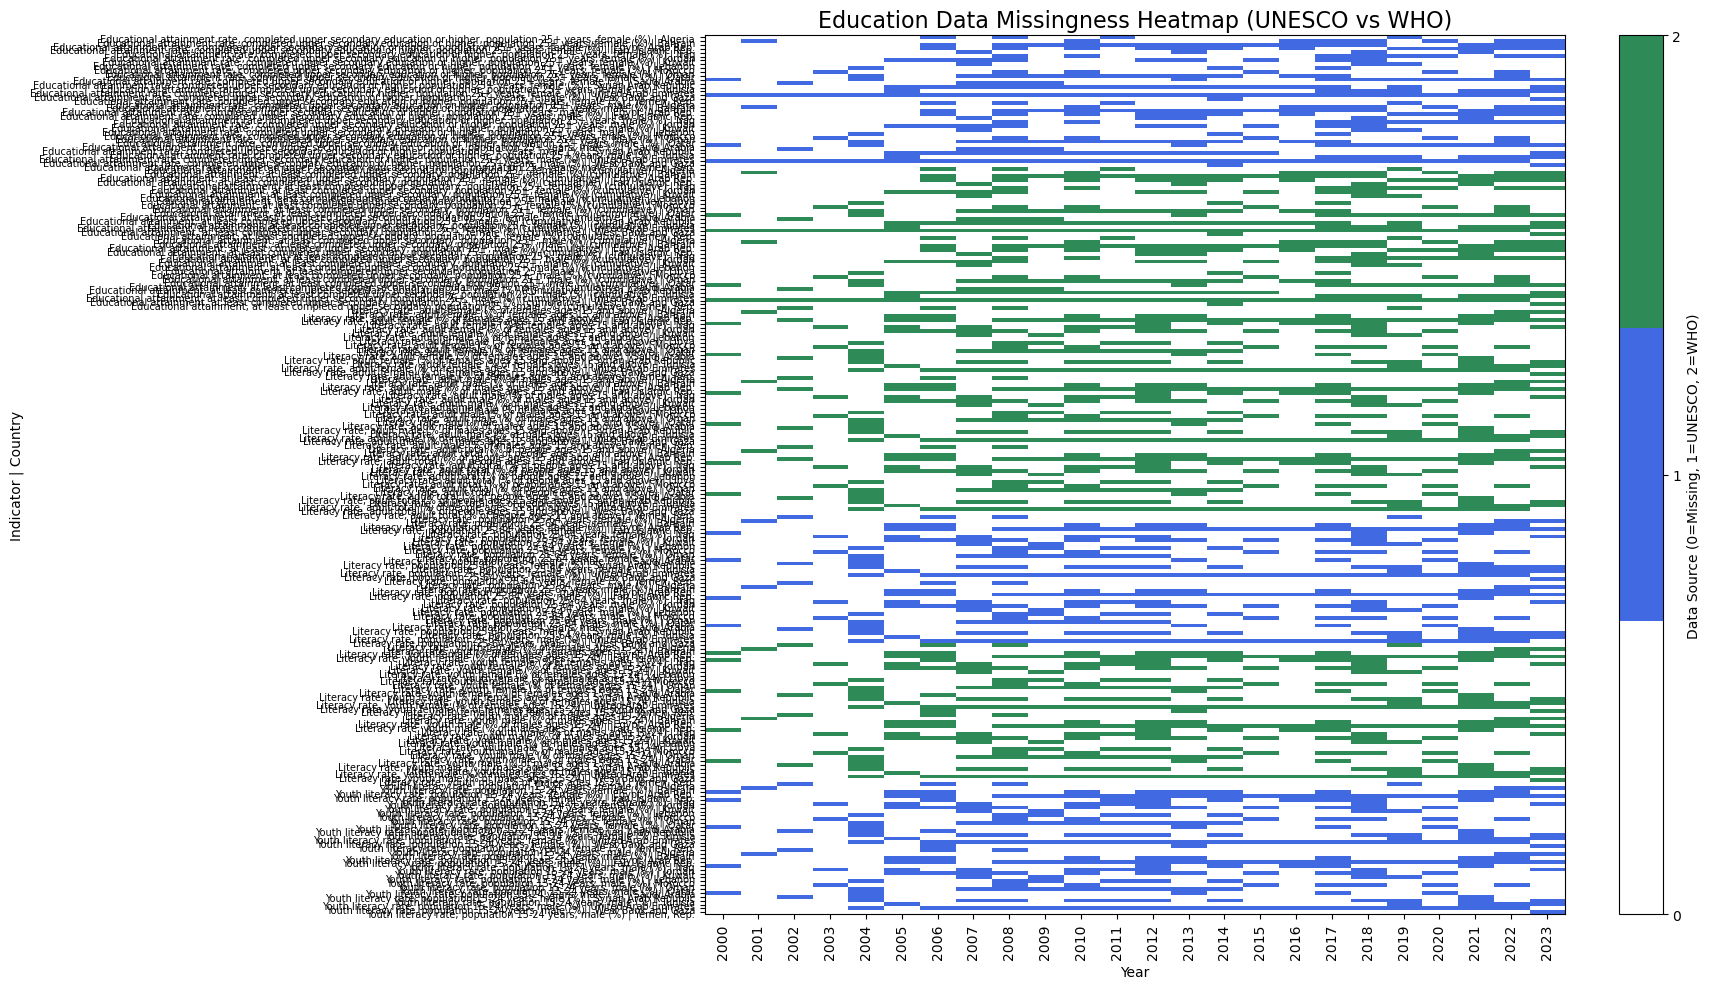

In [71]:

plt.figure(figsize=(18, 10))

# Custom colormap: 0=white, 1=blue, 2=green

cmap = ListedColormap(["white", "royalblue", "seagreen"])

plt.imshow(heatmap_df.T, aspect="auto", cmap=cmap)

plt.colorbar(
    ticks=[0, 1, 2],
    label="Data Source (0=Missing, 1=UNESCO, 2=WHO)"
)

plt.yticks(
    ticks=np.arange(len(heatmap_df.columns)),
    labels=[f"{ind} | {cty}" for ind, cty in heatmap_df.columns],
    fontsize=7
)

plt.xticks(
    ticks=np.arange(len(heatmap_df.index)),
    labels=heatmap_df.index,
    rotation=90
)

plt.title("Education Data Missingness Heatmap (UNESCO vs WHO)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Indicator | Country")

plt.tight_layout()
plt.show()


In [72]:
summary_ind = merged_edu.groupby("indicator_name")["missing_code"].apply(
    lambda x: (x==0).mean()
).sort_values()

summary_ind


indicator_name
Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)    0.644608
Educational attainment rate, completed upper secondary education or higher, population 25+ years, male (%)      0.647059
Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)             0.664352
Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)               0.666667
Youth literacy rate, population 15-24 years, female (%)                                                         0.666667
Literacy rate, population 25-64 years, male (%)                                                                 0.684896
Literacy rate, youth female (% of females ages 15-24)                                                           0.685185
Youth literacy rate, population 15-24 years, male (%)                                                           0.688725
Literacy rate, po

In [73]:
summary_cty = merged_edu.groupby("country_name")["missing_code"].apply(
    lambda x: (x==0).mean()
).sort_values()

summary_cty


country_name
West Bank and Gaza      0.185897
Iran, Islamic Rep.      0.317308
Tunisia                 0.503205
Egypt, Arab Rep.        0.564103
Kuwait                  0.567308
Qatar                   0.599359
Jordan                  0.660256
Oman                    0.692308
Saudi Arabia            0.727564
United Arab Emirates    0.766026
Iraq                    0.769231
Morocco                 0.788462
Bahrain                 0.810897
Lebanon                 0.846154
Algeria                 0.849359
Syrian Arab Republic    0.855769
Yemen, Rep.             0.937500
Libya                   1.000000
Name: missing_code, dtype: float64

In [74]:
coverage = {
    "UNESCO": (merged_edu["unesco_exists"]=="EXISTS").mean(),
    "WHO": (merged_edu["who_exists"]=="EXISTS").mean()
}

coverage


{'UNESCO': 0.14629221732745962, 'WHO': 0.17180616740088106}

AttributeError: module 'matplotlib.pyplot' has no attribute 'hide'

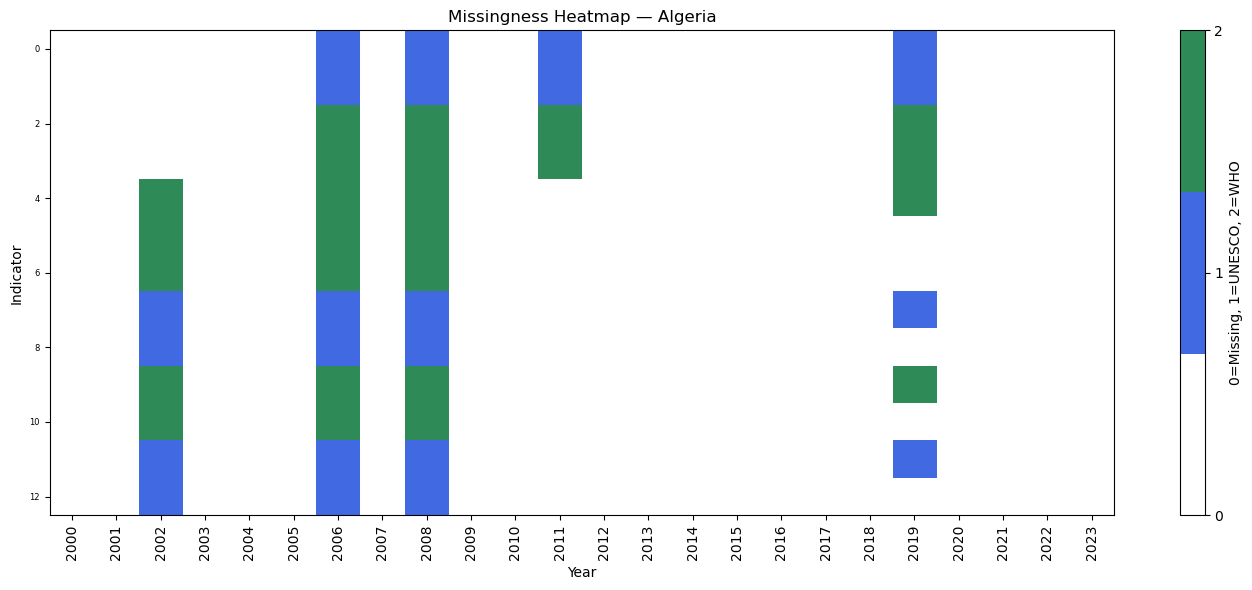

In [75]:
countries = merged_edu["country_name"].unique()

for c in countries:
    sub = merged_edu[merged_edu["country_name"] == c]

    sub_pivot = sub.pivot_table(
        index="year",
        columns="indicator_name",
        values="missing_code",
        aggfunc="max"
    )

    plt.figure(figsize=(14, 6))
    plt.imshow(sub_pivot.T, aspect="auto", cmap=cmap)
    plt.title(f"Missingness Heatmap — {c}")
    plt.xlabel("Year")
    plt.ylabel("Indicator")
    plt.colorbar(ticks=[0,1,2], label="0=Missing, 1=UNESCO, 2=WHO")
    plt.xticks(ticks=np.arange(len(sub_pivot.index)), labels=sub_pivot.index, rotation=90)
    plt.yticks(fontsize=6)
    plt.tight_layout()
    plt.hide()


## Creating a Flag

In [76]:
education_indicators = ['Literacy rate, population 25-64 years, male (%)','Literacy rate, population 25-64 years, female (%)',
          'Youth literacy rate, population 15-24 years, male (%)','Youth literacy rate, population 15-24 years, female (%)',
          'Educational attainment rate, completed upper secondary education or higher, population 25+ years, male (%)',
          'Educational attainment rate, completed upper secondary education or higher, population 25+ years, female (%)'
          ,'Educational attainment, at least completed upper secondary, population 25+, female (%) (cumulative)',
        "Educational attainment, at least completed upper secondary, population 25+, male (%) (cumulative)",
        "Literacy rate, adult female (% of females ages 15 and above)",
        "Literacy rate, adult male (% of males ages 15 and above)",
        "Literacy rate, adult total (% of people ages 15 and above)",
        "Literacy rate, youth female (% of females ages 15-24)",
        "Literacy rate, youth male (% of males ages 15-24)"
        ]

In [77]:
df['source_reliable'] = df['indicator_name'].apply(
    lambda x: 'low' if x in education_indicators else 'high'
)


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_3874/853173716.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['source_reliable'] = df['indicator_name'].apply(


In [78]:
df['source_reliable'].value_counts()

source_reliable
high    21744
low      3947
Name: count, dtype: int64

#### Created this flag to be able to filter them out in Tableau to create the Missingness Sheet

## Exploring the distribution of missing values 

In [79]:
clean_df = df[df['source_reliable'] == "high"].copy()
edu_df = df[df['source_reliable'] == "low"].copy()



In [80]:
clean_df.isna().sum()

country_name          0
year                  0
indicator_id          0
indicator_name        0
value              3725
unit_type             0
source                0
source_reliable       0
dtype: int64

In [81]:
null_rate = clean_df.groupby("indicator_name")["value"].apply(
    lambda x: x.isna().mean()
)

<Axes: title={'center': 'Missing by Indicators'}, xlabel='indicator_name'>

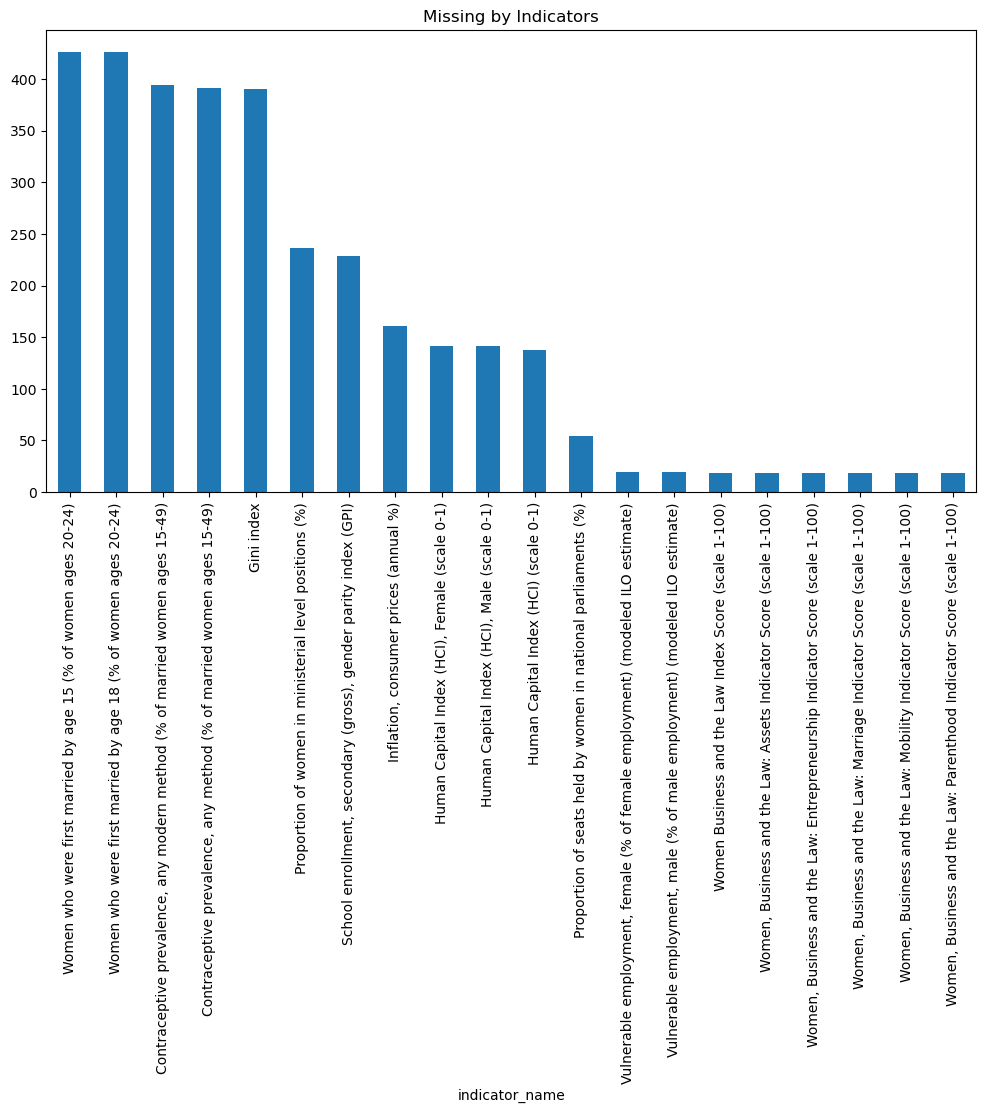

In [82]:
clean_df.groupby('indicator_name')['value'].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(20).plot(kind='bar',figsize=(12,6),title="Missing by Indicators")

In [83]:
clean_df.groupby('indicator_name')['value'].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(20)

indicator_name
Women who were first married by age 15 (% of women ages 20-24)                   426
Women who were first married by age 18 (% of women ages 20-24)                   426
Contraceptive prevalence, any modern method (% of married women ages 15-49)      394
Contraceptive prevalence, any method (% of married women ages 15-49)             391
Gini index                                                                       390
Proportion of women in ministerial level positions (%)                           236
School enrollment, secondary (gross), gender parity index (GPI)                  229
Inflation, consumer prices (annual %)                                            161
Human Capital Index (HCI), Female (scale 0-1)                                    141
Human Capital Index (HCI), Male (scale 0-1)                                      141
Human Capital Index (HCI) (scale 0-1)                                            138
Proportion of seats held by women in national parl

In [84]:
def indicator_gap_profile(ind_name):
    df_i = clean_df[clean_df["indicator_name"] == ind_name].copy()
    df_i = df_i.sort_values(["country_name", "year"])
    df_i["is_null"] = df_i["value"].isna()

    return df_i.groupby("country_name")["is_null"].mean().sort_values(ascending=False)


indicator_gap_profile("Gini index")


country_name
Libya                   1.00
Saudi Arabia            1.00
Oman                    1.00
Kuwait                  1.00
Bahrain                 1.00
Algeria                 0.96
Qatar                   0.96
United Arab Emirates    0.92
Yemen, Rep.             0.92
Lebanon                 0.92
Iraq                    0.88
Morocco                 0.88
Jordan                  0.84
Syrian Arab Republic    0.84
Tunisia                 0.80
Egypt, Arab Rep.        0.68
West Bank and Gaza      0.64
Iran, Islamic Rep.      0.36
Name: is_null, dtype: float64

In [85]:
def indicator_year_missing(ind_name):
    df_i = clean_df[clean_df["indicator_name"] == ind_name]
    return df_i.groupby("year")["value"].apply(lambda x: x.isna().mean())

indicator_year_missing("Human Capital Index (HCI) (scale 0-1)")



year
2010    0.333333
2011    1.000000
2012    1.000000
2013    1.000000
2014    1.000000
2015    1.000000
2016    1.000000
2017    0.111111
2018    0.111111
2019    1.000000
2020    0.111111
Name: value, dtype: float64

In [86]:
missing_summary = clean_df.groupby("indicator_name")["value"].apply(lambda x: x.isna().mean())


In [87]:
missing_summary

indicator_name
A woman can apply for a passport in the same way as a man (1=yes; 0=no)                         0.040000
A woman can be "head of household" in the same way as a man (1=yes; 0=no)                       0.040000
A woman can choose where to live in the same way as a man (1=yes; 0=no)                         0.040000
A woman can get a job in the same way as a man (1=yes; 0=no)                                    0.040000
A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)                 0.040000
A woman can open a bank account in the same way as a man (1=yes; 0=no)                          0.040000
A woman can register a business in the same way as a man (1=yes; 0=no)                          0.040000
A woman can sign a contract in the same way as a man (1=yes; 0=no)                              0.040000
A woman can travel outside her home in the same way as a man (1=yes; 0=no)                      0.040000
A woman can travel outside the country i

In [88]:
def classify(m):
    if m > 0.75: 
        return "severely incomplete"
    elif m > 0.45:
        return "high missingness"
    elif m > 0.20:
        return "moderate missingness"
    else:
        return "low missingness"

indicator_class = missing_summary.apply(classify)

indicator_class



indicator_name
A woman can apply for a passport in the same way as a man (1=yes; 0=no)                              low missingness
A woman can be "head of household" in the same way as a man (1=yes; 0=no)                            low missingness
A woman can choose where to live in the same way as a man (1=yes; 0=no)                              low missingness
A woman can get a job in the same way as a man (1=yes; 0=no)                                         low missingness
A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)                      low missingness
A woman can open a bank account in the same way as a man (1=yes; 0=no)                               low missingness
A woman can register a business in the same way as a man (1=yes; 0=no)                               low missingness
A woman can sign a contract in the same way as a man (1=yes; 0=no)                                   low missingness
A woman can travel outside her home in the same w

| Category                             | Cleaning Strategy                                        | Use in Dashboard                    |
| ------------------------------------ | -------------------------------------------------------- | ----------------------------------- |
| **Severely incomplete** (>75% nulls) | Drop from trend analysis; keep as “data desert evidence” | Missingness sheet only              |
| **High missingness** (45–75%)        | Partial cleaning; no long interpolations                 | Trend lines for countries with data |
| **Moderate missingness**             | Safe for interpolation (short gaps)                      | OK for modeling & trends            |
| **Low missingness**                  | Full cleaning                                            | Core dashboard metrics              |


In [89]:
# Cleaning rules based on your classification
CLEANING_RULES = {
    "low missingness": "interpolate_full",
    "moderate missingness": "interpolate_safe",
    "high missingness": "interpolate_short",
    "severely incomplete": "keep_raw"
}

def interpolate_full(clean_df):
    clean_df = clean_df.sort_values("year").copy()
    clean_df["value"] = clean_df["value"].infer_objects(copy=False).interpolate(method="linear", limit_direction="both")
    return clean_df


def interpolate_safe(clean_df):
    clean_df = clean_df.sort_values("year")
    clean_df["value"] = clean_df["value"].infer_objects(copy=False).interpolate(method="linear", limit_direction="both", limit=3)
    return clean_df

def interpolate_short(clean_df):
    clean_df = clean_df.sort_values("year")
    clean_df["value"] = clean_df["value"].infer_objects(copy=False).interpolate(method="linear", limit_direction="both", limit=1)
    return clean_df

def keep_raw(clean_df):
    return clean_df


In [90]:
clean_df.isna().sum()

country_name          0
year                  0
indicator_id          0
indicator_name        0
value              3725
unit_type             0
source                0
source_reliable       0
dtype: int64

In [93]:
from tqdm import tqdm

CLEANING_FUNCS = {
    "interpolate_full": interpolate_full,
    "interpolate_safe": interpolate_safe,
    "interpolate_short": interpolate_safe,  # because short gaps likely <2 years
    "keep_raw": keep_raw
}


cleaned_frames = []
clean_df["value"] = pd.to_numeric(clean_df["value"], errors="coerce")

for ind, group in tqdm(clean_df.groupby("indicator_name")):
    rule = CLEANING_RULES.get(indicator_class[ind], "keep_raw")
    func = CLEANING_FUNCS[rule]

    # Apply cleaning rule per country — NO warnings, because we select columns explicitly
    cleaned = (
        group[["country_name", "year", "value"]]
        .sort_values("year")
        .groupby("country_name", group_keys=False)
        .apply(func)
        .reset_index(drop=True)
    )
    
    # Merge back all original columns
    cleaned_full = cleaned.merge(
    group.drop(columns=["value"]),   # keep metadata
    on=["country_name", "year"],
    how="left"
)

    
    cleaned_frames.append(cleaned_full)

clean_df = pd.concat(cleaned_frames, ignore_index=True)


  0%|          | 0/50 [00:00<?, ?it/s]/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_3874/2760267995.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(func)
/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_3874/2760267995.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(func)
/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_3874/2760267995.py:23: Deprecat

In [94]:
clean_df.isna().sum()

country_name          0
year                  0
value              2458
indicator_id          0
indicator_name        0
unit_type             0
source                0
source_reliable       0
dtype: int64

In [99]:
clean_df.groupby("year")["value"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(10)

year
2001    123
2000    107
2011    107
2024    107
2010    104
2013    104
2020    103
2012    102
2002    101
2017    101
Name: value, dtype: int64

In [100]:
clean_df = clean_df[clean_df['year'] != 2024]

In [101]:
clean_df["year"].max()


2023

In [103]:
clean_df.isna().sum()

country_name          0
year                  0
value              2351
indicator_id          0
indicator_name        0
unit_type             0
source                0
source_reliable       0
dtype: int64

In [106]:
remaining_nulls = (
    clean_df[clean_df["value"].isna()]
    .groupby("indicator_name")
    .size()
    .sort_values(ascending=False)
)

remaining_nulls


indicator_name
Women who were first married by age 15 (% of women ages 20-24)                 408
Women who were first married by age 18 (% of women ages 20-24)                 408
Contraceptive prevalence, any modern method (% of married women ages 15-49)    376
Contraceptive prevalence, any method (% of married women ages 15-49)           373
Gini index                                                                     372
School enrollment, secondary (gross), gender parity index (GPI)                107
Inflation, consumer prices (annual %)                                          106
Proportion of women in ministerial level positions (%)                          61
Human Capital Index (HCI), Female (scale 0-1)                                   39
Human Capital Index (HCI), Male (scale 0-1)                                     39
Human Capital Index (HCI) (scale 0-1)                                           38
Proportion of seats held by women in national parliaments (%)           

In [ ]:
to_drop = []

In [108]:
missing_rate_after = (
    clean_df.isna()
    .groupby(clean_df["indicator_name"])
    .mean()["value"]
)

indicator_class_after = missing_rate_after.apply(classify)

indicator_class_after


indicator_name
A woman can apply for a passport in the same way as a man (1=yes; 0=no)                              low missingness
A woman can be "head of household" in the same way as a man (1=yes; 0=no)                            low missingness
A woman can choose where to live in the same way as a man (1=yes; 0=no)                              low missingness
A woman can get a job in the same way as a man (1=yes; 0=no)                                         low missingness
A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)                      low missingness
A woman can open a bank account in the same way as a man (1=yes; 0=no)                               low missingness
A woman can register a business in the same way as a man (1=yes; 0=no)                               low missingness
A woman can sign a contract in the same way as a man (1=yes; 0=no)                                   low missingness
A woman can travel outside her home in the same w

| Indicator                            | Null Count | Reason for Missingness                                                    | Recommended Action                                   |
| ------------------------------------ | ---------- | ------------------------------------------------------------------------- | ---------------------------------------------------- |
| Women married by age 15 (%)          | 408        | Demographic & Health Surveys (DHS) irregular; many countries never report | **Keep raw + show missingness**                      |
| Women married by age 18 (%)          | 408        | Same as above                                                             | **Keep raw + show missingness**                      |
| Contraceptive prevalence, modern     | 376        | DHS reports only certain years                                            | **Keep raw OR drop** (if not critical)               |
| Contraceptive prevalence, any method | 373        | Same as above                                                             | **Keep raw OR drop**                                 |
| Gini Index                           | 372        | Very sparse; many GCC countries never report inequality data              | **Drop for ML; keep for dashboard with missingness** |
| School enrollment GPI (secondary)    | 107        | Missing for fragile states + older years                                  | **Interpolate short + keep**                         |
| Inflation (annual %)                 | 106        | Missing in conflict periods (Libya, Yemen, Syria)                         | **Interpolate full** (economic data is smooth)       |
| Women ministers (%)                  | 61         | UNDP updates irregularly                                                  | **Keep raw**                                         |
| HCI (Female, Male, Total)            | 39–41      | New indicator; only reported since 2018                                   | **Do not interpolate; keep raw**                     |
| Seats in Parliament (%)              | 24         | Missing early 2000s for some countries                                    | **Interpolate safe**                                 |


In [112]:
# STRUCTURAL indicators (cannot be interpolated)
structural_incomplete = [
    "Women who were first married by age 15 (% of women ages 20-24)",
    "Women who were first married by age 18 (% of women ages 20-24)",
    "Contraceptive prevalence, any method (% of married women ages 15-49)",
    "Contraceptive prevalence, any modern method (% of married women ages 15-49)",
    "Gini index"
]

# Time-series but sparse
safe_interpolation = [
    "Proportion of seats held by women in national parliaments (%)",
    "School enrollment, secondary (gross), gender parity index (GPI)"
]

# Economic indicators (smooth — safe for full interpolation)
smooth_indicators = [
    "Inflation, consumer prices (annual %)"
]

# Should remain raw (new indicators — too few years)
hci_indicators = [
    "Human Capital Index (HCI) (scale 0-1)",
    "Human Capital Index (HCI), Female (scale 0-1)",
    "Human Capital Index (HCI), Male (scale 0-1)"
]


In [113]:


# 1 — drop structural indicators if desired
#clean_df = clean_df[~clean_df["indicator_name"].isin(structural_incomplete)]

# 2 — interpolate safe indicators
clean_df.loc[clean_df["indicator_name"].isin(safe_interpolation), "value"] = (
    clean_df[clean_df["indicator_name"].isin(safe_interpolation)]
    .sort_values("year")
    .groupby(["indicator_name", "country_name"])["value"]
    .transform(lambda x: x.interpolate(limit=3))
)

# 3 — interpolate smooth economic indicators fully
clean_df.loc[clean_df["indicator_name"].isin(smooth_indicators), "value"] = (
    clean_df[clean_df["indicator_name"].isin(smooth_indicators)]
    .sort_values("year")
    .groupby(["indicator_name", "country_name"])["value"]
    .transform(lambda x: x.interpolate(limit_direction="both"))
)

# 4 — HCI indicators → do not interpolate
# They remain raw intentionally


In [114]:
clean_df.isna().sum()

country_name          0
year                  0
value              2219
indicator_id          0
indicator_name        0
unit_type             0
source                0
source_reliable       0
dtype: int64

In [115]:
ml_df = clean_df[~clean_df["indicator_name"].isin(structural_incomplete)].copy()

ml_df.info()
ml_df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 18738 entries, 0 to 21725
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_name     18738 non-null  object 
 1   year             18738 non-null  int64  
 2   value            18456 non-null  float64
 3   indicator_id     18738 non-null  object 
 4   indicator_name   18738 non-null  object 
 5   unit_type        18738 non-null  object 
 6   source           18738 non-null  object 
 7   source_reliable  18738 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 1.3+ MB


country_name         0
year                 0
value              282
indicator_id         0
indicator_name       0
unit_type            0
source               0
source_reliable      0
dtype: int64

In [117]:
edu_df = edu_df[edu_df['year'] != 2024]

In [118]:
clean_df["data_exists"] = clean_df["value"].notna()
edu_df["data_exists"] = edu_df["value"].notna()

In [120]:
final_df_for_tableau = pd.concat([clean_df, edu_df], ignore_index=True)

final_df_for_tableau = final_df_for_tableau.sort_values(
    ["country_name", "indicator_name", "year"]
).reset_index(drop=True)

final_df_for_tableau.info()
final_df_for_tableau.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24719 entries, 0 to 24718
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country_name     24719 non-null  object
 1   year             24719 non-null  int64 
 2   value            20412 non-null  object
 3   indicator_id     24719 non-null  object
 4   indicator_name   24719 non-null  object
 5   unit_type        24719 non-null  object
 6   source           24719 non-null  object
 7   source_reliable  24719 non-null  object
 8   data_exists      24719 non-null  bool  
dtypes: bool(1), int64(1), object(7)
memory usage: 1.5+ MB


,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,data_exists
0,Algeria,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,True
1,Algeria,2001,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,True
2,Algeria,2002,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,True
3,Algeria,2003,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,True
4,Algeria,2004,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,True


In [122]:
region_map = {
    'Bahrain': 'GCC',
    'Kuwait': 'GCC',
    'Oman': 'GCC',
    'Qatar': 'GCC',
    'Saudi Arabia': 'GCC',
    'United Arab Emirates': 'GCC',

    'Egypt, Arab Rep.': 'North Africa',
    'Libya': 'North Africa',
    'Morocco': 'North Africa',
    'Algeria': 'North Africa',
    'Tunisia': 'North Africa',

    'Jordan': 'Levant',
    'Lebanon': 'Levant',
    'West Bank and Gaza': 'Levant',
    'Syrian Arab Republic' : 'Levant',
    
    
    'Yemen, Rep.' : 'Other',
    'Iran, Islamic Rep.' : 'Other',
    'Iraq' : 'Other'
    
}


In [135]:
ml_df["region"] = ml_df["country_name"].map(region_map)

In [123]:
final_df_for_tableau['region'] = final_df_for_tableau['country_name'].map(region_map)

In [124]:
category_map = {
    # Women, Business and the Law
    "Women Business and the Law Index Score (scale 1-100)": "WBL",
    "Women, Business and the Law: Mobility Indicator Score (scale 1-100)": "WBL",
    "Women, Business and the Law: Workplace Indicator Score (scale 1-100)": "WBL",
    "Women, Business and the Law: Pay Indicator Score (scale 1-100)": "WBL",
    "Women, Business and the Law: Marriage Indicator Score (scale 1-100)": "WBL",
    "Women, Business and the Law: Parenthood Indicator Score (scale 1-100)": "WBL",
    "Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)": "WBL",
    "Women, Business and the Law: Assets Indicator Score (scale 1-100)": "WBL",

    # Socioeconomic
    "GDP per capita (current US$)": "Economy",
    "Gini index": "Economy",
    "Inflation, consumer prices (annual %)": "Economy",

    # Demographics
    "Birth rate, crude (per 1,000 people)": "Demographics",
    "Death rate, crude (per 1,000 people)": "Demographics",
    "Population, total": "Demographics",

    # Education
    "School enrollment, secondary (gross), gender parity index (GPI)": "Education",
    "Human Capital Index (HCI) (scale 0-1)": "Education",
    "Human Capital Index (HCI), Female (scale 0-1)": "Education",
    "Human Capital Index (HCI), Male (scale 0-1)": "Education",

    # Labor
    "Employment to population ratio, 15+, female (%) (modeled ILO estimate)": "Labor",
    "Employment to population ratio, 15+, male (%) (modeled ILO estimate)": "Labor",
    "Unemployment, female (% of female labor force) (modeled ILO estimate)": "Labor",
    "Unemployment, male (% of male labor force) (modeled ILO estimate)": "Labor",
    "Vulnerable employment, female (% of female employment) (modeled ILO estimate)": "Labor",
    "Vulnerable employment, male (% of male employment) (modeled ILO estimate)": "Labor",

    # Marriage & Family
    "Women who were first married by age 15 (% of women ages 20-24)": "Marriage",
    "Women who were first married by age 18 (% of women ages 20-24)": "Marriage",

    # Health & Fertility
    "Adolescent fertility rate (births per 1,000 women ages 15-19)": "Health",
    "Maternal mortality ratio (modeled estimate, per 100,000 live births)": "Health",
    "Life expectancy at birth, female (years)": "Health",
    "Life expectancy at birth, male (years)": "Health",
    "Contraceptive prevalence, any method (% of married women ages 15-49)": "Health",
    "Contraceptive prevalence, any modern method (% of married women ages 15-49)": "Health",

    # Governance & Representation
    "Proportion of seats held by women in national parliaments (%)": "Governance",
    "Proportion of women in ministerial level positions (%)": "Governance",
}


In [125]:
final_df_for_tableau['category'] = final_df_for_tableau['indicator_name'].map(category_map)

final_df_for_tableau["category"] = final_df_for_tableau["category"].fillna("Other")


In [136]:

ml_df['category'] = ml_df['indicator_name'].map(category_map)

ml_df["category"] = ml_df["category"].fillna("Other")

In [126]:
final_df_for_tableau["region"].isna().sum()



0

In [127]:
final_df_for_tableau["category"].isna().sum()

0

In [128]:
structurally_incomplete = [
    "Human Capital Index (HCI), Female (scale 0-1)",
    "Human Capital Index (HCI), Male (scale 0-1)",
    "Human Capital Index (HCI) (scale 0-1)"
]

ml_df = ml_df[~ml_df["indicator_name"].isin(structurally_incomplete)].copy()

In [129]:
import pandas as pd

remaining = ml_df.groupby("indicator_name")["value"].apply(lambda x: x.isna().mean())
print("Missingness:\n", remaining)


Missingness:
 indicator_name
A woman can apply for a passport in the same way as a man (1=yes; 0=no)                         0.000000
A woman can be "head of household" in the same way as a man (1=yes; 0=no)                       0.000000
A woman can choose where to live in the same way as a man (1=yes; 0=no)                         0.000000
A woman can get a job in the same way as a man (1=yes; 0=no)                                    0.000000
A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)                 0.000000
A woman can open a bank account in the same way as a man (1=yes; 0=no)                          0.000000
A woman can register a business in the same way as a man (1=yes; 0=no)                          0.000000
A woman can sign a contract in the same way as a man (1=yes; 0=no)                              0.000000
A woman can travel outside her home in the same way as a man (1=yes; 0=no)                      0.000000
A woman can travel outside

In [130]:
ml_df.isna().sum()

country_name         0
year                 0
value              166
indicator_id         0
indicator_name       0
unit_type            0
source               0
source_reliable      0
dtype: int64

In [132]:
# Indicators with moderate missingness
moderate_indicators = [
    "School enrollment, secondary (gross), gender parity index (GPI)"
]

# Indicators with small gaps
small_gap_indicators = [
    "Proportion of women in ministerial level positions (%)",
    "Proportion of seats held by women in national parliaments (%)"
]

cleaned_blocks = []

for ind, group in ml_df.groupby("indicator_name"):

    df = group.sort_values(["country_name", "year"]).copy()

    # --- MODERATE MISSINGNESS (use limit-based interpolation) ---
    if ind == "School enrollment, secondary (gross), gender parity index (GPI)":
        df["value"] = (
            df.groupby("country_name")["value"]
              .transform(lambda s: s.interpolate(limit=3, limit_direction="both"))
        )

    # --- SMALL GAPS (forward fill + backward fill) ---
    elif ind in [
        "Proportion of women in ministerial level positions (%)",
        "Proportion of seats held by women in national parliaments (%)"
    ]:
        df["value"] = (
            df.groupby("country_name")["value"]
              .transform(lambda s: s.ffill().bfill())
        )

    # Add back to list
    cleaned_blocks.append(df)

# Merge back
ml_df = pd.concat(cleaned_blocks, ignore_index=True)

# Verify
print(ml_df["value"].isna().sum())


105


In [133]:
remaining = ml_df.groupby("indicator_name")["value"].apply(lambda x: x.isna().mean())
print("Missingness:\n", remaining)

Missingness:
 indicator_name
A woman can apply for a passport in the same way as a man (1=yes; 0=no)                         0.000000
A woman can be "head of household" in the same way as a man (1=yes; 0=no)                       0.000000
A woman can choose where to live in the same way as a man (1=yes; 0=no)                         0.000000
A woman can get a job in the same way as a man (1=yes; 0=no)                                    0.000000
A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)                 0.000000
A woman can open a bank account in the same way as a man (1=yes; 0=no)                          0.000000
A woman can register a business in the same way as a man (1=yes; 0=no)                          0.000000
A woman can sign a contract in the same way as a man (1=yes; 0=no)                              0.000000
A woman can travel outside her home in the same way as a man (1=yes; 0=no)                      0.000000
A woman can travel outside

1. Proportion of Seats Held by Women in Parliament (%)= using regional initialization

For the first available year in each country, fill backward using:

regional average for that year (GCC / North Africa / Levant)

This preserves:

correctness at the time

reasonable starting anchor

avoids unrealistic interpolation from nothing

2. Proportion of Women in Ministerial Level Positions (%)

Option A: backward fill using regional average for the same year.
Option B: backward fill using the country’s first known value.

Option A

3. School Enrollment, Secondary (Gross), GPI

✔ Interpolate over longer gaps (limit=5)

Because education indicators:

Move gradually year to year

Rarely have sudden shocks

Missing sequences up to 3–5 years can still be interpolated safely

This will bring missingness close to 0–2% max.


In [139]:
REGIONAL_MEANS = (
    ml_df.groupby(["region", "year"])["value"]
         .mean()
         .reset_index()
         .rename(columns={"value": "regional_mean"})
)

def fill_with_regional_average(df):
    df = df.merge(REGIONAL_MEANS, on=["region", "year"], how="left")
    df["value"] = df["value"].fillna(df["regional_mean"])
    return df.drop(columns=["regional_mean"])


cleaned_list = []

for ind, group in ml_df.groupby("indicator_name"):
    df = group.sort_values(["country_name", "year"]).copy()

    # -------------------------
    # 1) PARLIAMENT & MINISTERS
    # -------------------------
    if ind in [
        "Proportion of seats held by women in national parliaments (%)",
        "Proportion of women in ministerial level positions (%)"
    ]:
        df["value"] = (
            df.groupby("country_name")["value"]
              .transform(lambda s: s.ffill().bfill())
        )
        df = fill_with_regional_average(df)

    # -------------------------
    # 2) GPI Enrollment
    # -------------------------
    elif ind == "School enrollment, secondary (gross), gender parity index (GPI)":
        df["value"] = (
            df.groupby("country_name")["value"]
              .transform(lambda s: s.interpolate(limit=5, limit_direction="both"))
        )
        df = fill_with_regional_average(df)

    cleaned_list.append(df)

ml_df = pd.concat(cleaned_list, ignore_index=True)

print("Remaining nulls:", ml_df["value"].isna().sum())


Remaining nulls: 0


In [140]:
ml_df.to_csv("data/feature_data.csv", index=False)